# `geo-tfidf`

# imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sklearn
import datasets
import duckdb
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotnine as p9
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import html
print(pd.__version__)
print(np.__version__)
print(sklearn.__version__)
print(datasets.__version__)
print(duckdb.__version__)


3.0.3
2.4.6
1.8.0
4.8.5
1.5.3


# path

In [2]:
DATA_DIR = Path.cwd().parent / "data"

print(f"data dir: {DATA_DIR}")
PLOT_DIR = Path.cwd().parent / "img"
print(f"plot dir: {PLOT_DIR}")

data dir: /mnt/data/projects/geo-tfidf/data
plot dir: /mnt/data/projects/geo-tfidf/img


# load dataset from huggingface

In [ ]:
# ds = datasets.load_dataset('wangrongsheng/ag_news', split='train[:5000]')
# print(ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


In [ ]:
# ds.save_to_disk(DATA_DIR)

Saving the dataset (0/1 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]

In [37]:
ds = datasets.load_from_disk(DATA_DIR)

In [38]:
print(ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


# pandas eda

In [4]:
df = pd.DataFrame(ds)
print(df)

                                                   text  label
0     Wall St. Bears Claw Back Into the Black (Reute...      2
1     Carlyle Looks Toward Commercial Aerospace (Reu...      2
2     Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3     Iraq Halts Oil Exports from Main Southern Pipe...      2
4     Oil prices soar to all-time record, posing new...      2
...                                                 ...    ...
4995  Court to hear medal appeal  Britain will find ...      0
4996  Guatemala to pay paramilitaries Guatemala's go...      0
4997  Particle collider edges forward Physicists tak...      0
4998  Oil Futures Rise to Record as Iraq Fighting Th...      2
4999  General Growth Properties to acquire Rouse for...      2

[5000 rows x 2 columns]


In [5]:
df.columns

Index(['text', 'label'], dtype='str')

In [6]:
df.label.unique()

array([2, 3, 1, 0])

In [7]:
# World (0), Sports (1), Business (2), Sci/Tech (3)
df = df.assign(
    text  = lambda d: d.text.map(html.unescape), # unescape html entities e.g. 39 before tokenizing
    label = lambda d: (
        d.label
        .astype("category")
        .cat.rename_categories({0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"})
    )
)

In [8]:
df.dtypes

text          str
label    category
dtype: object

In [9]:
print(df['label'].value_counts().sort_values())


label
Sports      1032
World       1235
Business    1236
Sci/Tech    1497
Name: count, dtype: int64


In [10]:
df.index

RangeIndex(start=0, stop=5000, step=1)

In [11]:
df['label']

0       Business
1       Business
2       Business
3       Business
4       Business
          ...   
4995       World
4996       World
4997       World
4998    Business
4999    Business
Name: label, Length: 5000, dtype: category
Categories (4, str): ['World', 'Sports', 'Business', 'Sci/Tech']

In [12]:
df.label.unique()

['Business', 'Sci/Tech', 'Sports', 'World']
Categories (4, str): ['World', 'Sports', 'Business', 'Sci/Tech']

In [13]:
df['text']

0       Wall St. Bears Claw Back Into the Black (Reute...
1       Carlyle Looks Toward Commercial Aerospace (Reu...
2       Oil and Economy Cloud Stocks' Outlook (Reuters...
3       Iraq Halts Oil Exports from Main Southern Pipe...
4       Oil prices soar to all-time record, posing new...
                              ...                        
4995    Court to hear medal appeal  Britain will find ...
4996    Guatemala to pay paramilitaries Guatemala's go...
4997    Particle collider edges forward Physicists tak...
4998    Oil Futures Rise to Record as Iraq Fighting Th...
4999    General Growth Properties to acquire Rouse for...
Name: text, Length: 5000, dtype: str

# wordcloud

In [14]:
text_str = df['text'].to_string()

In [15]:
wordcloud = WordCloud().generate(text=text_str)

In [16]:
# show wordcloud as image (without matplotlib)
#wordcloud_image = wordcloud.to_image()
#wordcloud_image.show()

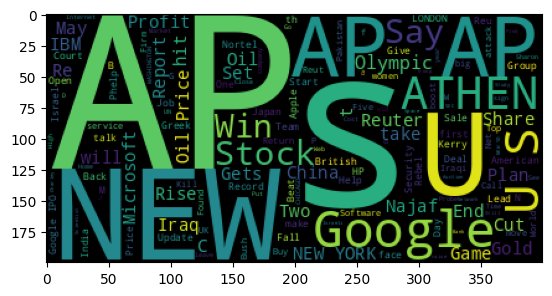

In [17]:
# show wordcloud with matplotlib
plt.imshow(wordcloud)

# tf-idf vectorize

We found the following issues with the tokens:

1. Domain stopwords - news-wire boilerplate words:

- reuters
- ap (Associated Press)
- afp (Agence France-Presse)

2. Generic words (not in sklearn's stop words):

- said 
- new

3. Misc:

- al (al-Qaeda?)

In [18]:
domain_stops = {"reuters", "ap", "afp", "said"}
my_stops = list(ENGLISH_STOP_WORDS | domain_stops)

vec = TfidfVectorizer(
      stop_words=my_stops,
      token_pattern=r"(?u)\b[a-z][a-z]+\b",   # letters only → drops "39", "11", etc.
      ngram_range=(1,2), # allow uni-gram and bi-gram tokens
      min_df=5,          # ignore terms in fewer than 5 docs — kills one-off bigrams
)
# vec = TfidfVectorizer(stop_words='english', max_features=5000)
X = vec.fit_transform(df['text'])

In [19]:
print(X.shape)

(5000, 5984)


In [20]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 103617 stored elements and shape (5000, 5984)>
  Coords	Values
  (0, 5721)	0.3890174518160951
  (0, 5009)	0.2287836868610401
  (0, 460)	0.2832204625893781
  (0, 896)	0.28898665485583247
  (0, 530)	0.24789173597614567
  (0, 4810)	0.22196372893434585
  (0, 4693)	0.2832204625893781
  (0, 5107)	0.19551976602717253
  (0, 1523)	0.28898665485583247
  (0, 410)	0.2738197430179455
  (0, 4678)	0.26987860574072686
  (0, 2155)	0.22636954556831998
  (0, 5722)	0.2832204625893781
  (0, 5723)	0.2016291369133497
  (1, 2998)	0.288322883924692
  (1, 985)	0.30976204503995736
  (1, 4044)	0.290071867566423
  (1, 2587)	0.2850112921675505
  (1, 1866)	0.23856899588854888
  (1, 2162)	0.20885472453397713
  (1, 3071)	0.2520968732736305
  (1, 1094)	0.3187597329602969
  (1, 3898)	0.3392353964592529
  (1, 1295)	0.27128157401899633
  (1, 2494)	0.2428687394978502
  :	:
  (4999, 3468)	0.08822388327744543
  (4999, 2168)	0.23223474984644352
  (4999, 4652)	0.097

In [21]:
type(X)

scipy.sparse._csr.csr_matrix

In [22]:
vocab = vec.get_feature_names_out()
len(vocab)

5984

In [23]:
type(vocab)

numpy.ndarray

In [24]:
print(vocab)

['aaron' 'aaron peirsol' 'abandoned' ... 'zire' 'zone' 'zurich']


In [25]:
type(vocab[0])

str

# tf-idf per-class mean

In [26]:
records = []
for label, idx in df.groupby('label').groups.items():
    means = np.asarray(X[idx].mean(axis=0)).ravel()
    top = means.argsort()[::-1][:5]
    records.extend(
        {'label': label, 'term': vocab[j], 'mean_tfidf': means[j]}
        for j in top
    )

In [27]:
mean_tfidf_per_class = (
    pd.DataFrame.from_records(records)
    .sort_values(
        ['label', 'mean_tfidf'],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)
print(mean_tfidf_per_class)

       label       term  mean_tfidf
0   Business        oil    0.033376
1   Business     google    0.026870
2   Business        new    0.024676
3   Business     prices    0.023910
4   Business     stocks    0.021668
5   Sci/Tech        new    0.019528
6   Sci/Tech  microsoft    0.018934
7   Sci/Tech   software    0.016134
8   Sci/Tech    windows    0.014509
9   Sci/Tech      space    0.012743
10    Sports     athens    0.043756
11    Sports    olympic    0.032056
12    Sports       gold    0.028303
13    Sports   olympics    0.023831
14    Sports       team    0.021195
15     World      najaf    0.021395
16     World       iraq    0.019343
17     World   minister    0.016715
18     World         al    0.014201
19     World  president    0.013857


# plot with plotnine

In [28]:
mean_tfidf_per_class.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
label,Business,Business,Business,Business,Business,Sci/Tech,Sci/Tech,Sci/Tech,Sci/Tech,Sci/Tech,Sports,Sports,Sports,Sports,Sports,World,World,World,World,World
term,oil,google,new,prices,stocks,new,microsoft,software,windows,space,athens,olympic,gold,olympics,team,najaf,iraq,minister,al,president
mean_tfidf,0.033376,0.02687,0.024676,0.02391,0.021668,0.019528,0.018934,0.016134,0.014509,0.012743,0.043756,0.032056,0.028303,0.023831,0.021195,0.021395,0.019343,0.016715,0.014201,0.013857


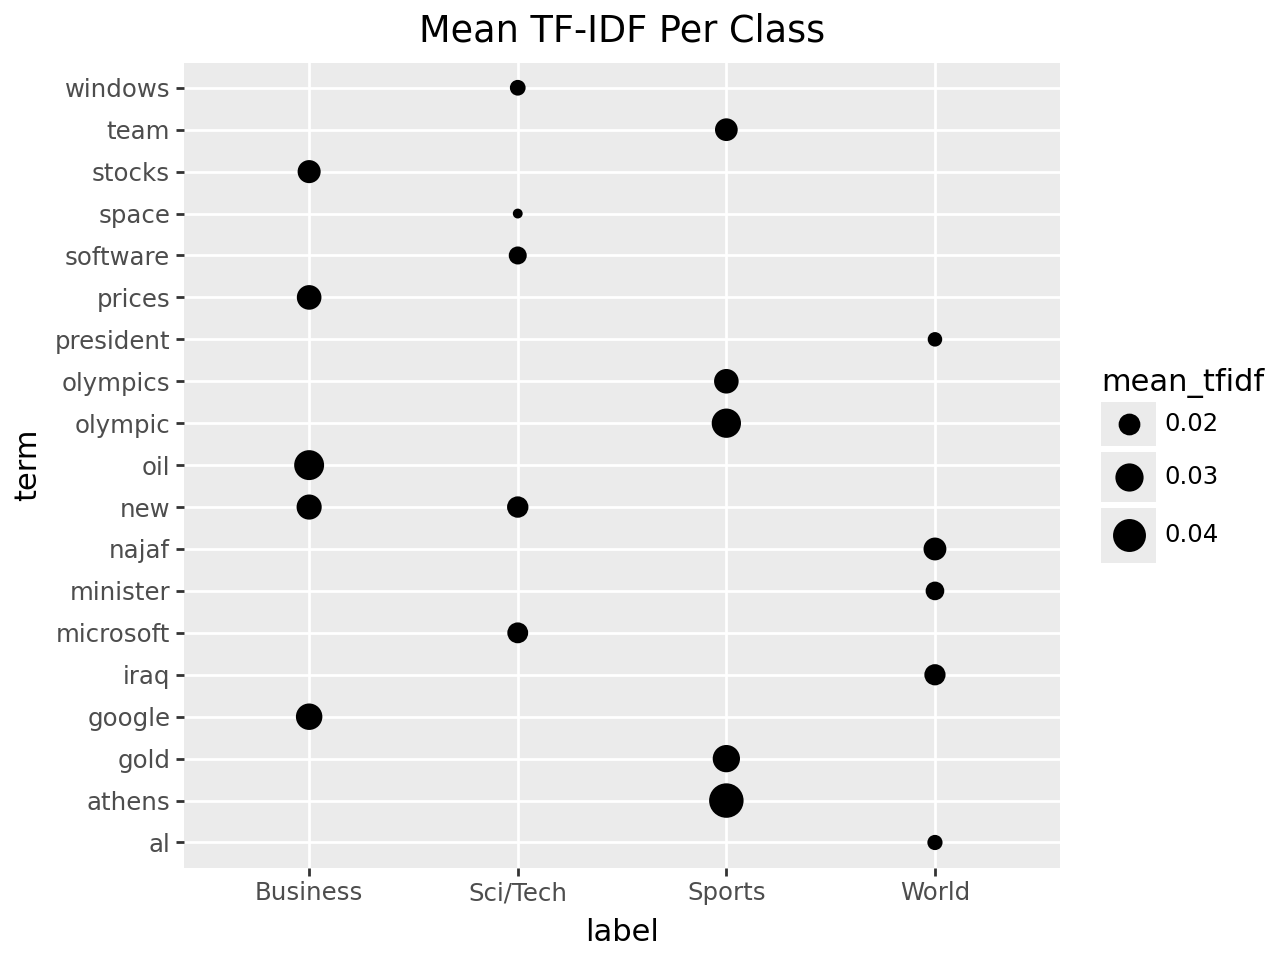

In [29]:
plot = (
    p9.ggplot(data=mean_tfidf_per_class, mapping=p9.aes(x="label", y="term", size="mean_tfidf")) +
    p9.geom_point() +
    p9.theme_grey() +
    p9.labs(title="Mean TF-IDF Per Class")
)
plot

In [30]:
plot.save(PLOT_DIR / "plot.png")

/mnt/data/projects/geo-tfidf/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/mnt/data/projects/geo-tfidf/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /mnt/data/projects/geo-tfidf/img/plot.png


# sql eda

In [31]:
query = """
select * 
from df
"""


In [32]:
duckdb.sql(query).df()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",Business
...,...,...
4995,Court to hear medal appeal Britain will find ...,World
4996,Guatemala to pay paramilitaries Guatemala's go...,World
4997,Particle collider edges forward Physicists tak...,World
4998,Oil Futures Rise to Record as Iraq Fighting Th...,Business
